# CDS 2413 — Introduction to Data Science
## Deliverable 2: Machine Learning Models Report — Jupyter Notebook
### Dataset: Medical Insurance Cost Prediction
**Source:** [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## CLO3: Machine Learning Models

---
## PART A — PREPROCESSING (5 Points)

### 2. Load & Inspect Dataset

In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')

print(f"Shape: {df.shape[0]} records x {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: 1338 records x 7 columns

Column types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


### 3. Data Cleaning

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nNo missing values found — dataset is clean.")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0

No missing values found — dataset is clean.

Duplicate rows: 1
Duplicates removed. New shape: (1337, 7)


### 4. Encoding Categorical Variables

In [4]:
# Identify categorical variables
print("Categorical columns and their unique values:")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].unique()}")

# Encode categorical variables using Label Encoding
df_encoded = df.copy()
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_encoded['sex'] = le_sex.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le_smoker.fit_transform(df_encoded['smoker'])
df_encoded['region'] = le_region.fit_transform(df_encoded['region'])

print("\nEncoding mappings:")
print(f"  sex:    {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"  smoker: {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}")
print(f"  region: {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}")

print("\nEncoded dataset:")
df_encoded.head()

Categorical columns and their unique values:
  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']

Encoding mappings:
  sex:    {'female': np.int64(0), 'male': np.int64(1)}
  smoker: {'no': np.int64(0), 'yes': np.int64(1)}
  region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

Encoded dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.9000,0,1,3,"16,884.9240"
1,18,1,33.7700,1,0,2,"1,725.5523"
2,28,1,33.0000,3,0,2,"4,449.4620"
3,33,1,22.7050,0,0,1,"21,984.4706"
4,32,1,28.8800,0,0,1,"3,866.8552"


### 5. Detecting and Removing Outliers

In [5]:
# Detect outliers using IQR method for numerical columns
numerical_cols = ['age', 'bmi', 'children', 'charges']
print("Outlier Detection using IQR Method:")
print("=" * 50)

outlier_indices = []
for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_encoded[(df_encoded[col] < lower) | (df_encoded[col] > upper)]
    outlier_indices.extend(outliers.index.tolist())
    print(f"  {col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outliers={len(outliers)}")

# Remove duplicates from outlier indices and remove
outlier_indices = list(set(outlier_indices))
print(f"\nTotal unique outlier rows: {len(outlier_indices)}")
print(f"Dataset shape before removal: {df_encoded.shape}")

df_clean = df_encoded.drop(outlier_indices).reset_index(drop=True)
print(f"Dataset shape after removal:  {df_clean.shape}")
print(f"Rows removed: {len(outlier_indices)}")

Outlier Detection using IQR Method:
  age: Q1=27.00, Q3=51.00, IQR=24.00, Lower=-9.00, Upper=87.00, Outliers=0
  bmi: Q1=26.29, Q3=34.70, IQR=8.41, Lower=13.67, Upper=47.32, Outliers=9
  children: Q1=0.00, Q3=2.00, IQR=2.00, Lower=-3.00, Upper=5.00, Outliers=0
  charges: Q1=4746.34, Q3=16657.72, IQR=11911.37, Lower=-13120.72, Upper=34524.78, Outliers=139

Total unique outlier rows: 145
Dataset shape before removal: (1337, 7)
Dataset shape after removal:  (1192, 7)
Rows removed: 145


### 6. Splitting the Data

In [6]:
# Define features (X) and target (y) for REGRESSION
X = df_clean.drop('charges', axis=1)
y = df_clean['charges']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Summary (Regression):")
print(f"  Total samples:    {len(X)}")
print(f"  Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing samples:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Features: {list(X.columns)}")
print(f"  Target: charges")

Data Split Summary (Regression):
  Total samples:    1192
  Training samples: 953 (80%)
  Testing samples:  239 (20%)
  Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
  Target: charges


---
## PART B — REGRESSION MODELS (7 Points)

### 7. Building and Evaluating Regression Models

In [7]:
# ─── 1. Linear Regression ───
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("=" * 55)
print("  1. LINEAR REGRESSION")
print("=" * 55)
print(f"  MSE:  {mse_lr:,.2f}")
print(f"  R²:   {r2_lr:.4f}")
print("=" * 55)

  1. LINEAR REGRESSION
  MSE:  23,223,597.46
  R²:   0.6014


In [8]:
# ─── 2. Polynomial Regression (Degree 2) ───
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)
mse_pr = mean_squared_error(y_test, y_pred_pr)
r2_pr = r2_score(y_test, y_pred_pr)
print("=" * 55)
print("  2. POLYNOMIAL REGRESSION (Degree 2)")
print("=" * 55)
print(f"  MSE:  {mse_pr:,.2f}")
print(f"  R²:   {r2_pr:.4f}")
print("=" * 55)

  2. POLYNOMIAL REGRESSION (Degree 2)
  MSE:  21,411,728.40
  R²:   0.6325


In [9]:
# ─── 3. Ridge Regression ───
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print("=" * 55)
print("  3. RIDGE REGRESSION (alpha=1.0)")
print("=" * 55)
print(f"  MSE:  {mse_ridge:,.2f}")
print(f"  R²:   {r2_ridge:.4f}")
print("=" * 55)

  3. RIDGE REGRESSION (alpha=1.0)
  MSE:  23,128,273.75
  R²:   0.6030


In [10]:
# ─── 4. Lasso Regression ───
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print("=" * 55)
print("  4. LASSO REGRESSION (alpha=1.0)")
print("=" * 55)
print(f"  MSE:  {mse_lasso:,.2f}")
print(f"  R²:   {r2_lasso:.4f}")
print("=" * 55)

  4. LASSO REGRESSION (alpha=1.0)
  MSE:  23,220,977.03
  R²:   0.6015


In [11]:
# ─── 5. Elastic Net Regression ───
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
print("=" * 55)
print("  5. ELASTIC NET REGRESSION (alpha=1.0, l1_ratio=0.5)")
print("=" * 55)
print(f"  MSE:  {mse_elastic:,.2f}")
print(f"  R²:   {r2_elastic:.4f}")
print("=" * 55)

  5. ELASTIC NET REGRESSION (alpha=1.0, l1_ratio=0.5)
  MSE:  36,336,814.04
  R²:   0.3763


### 8. Model Comparison Table

In [12]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (Deg 2)', 'Ridge Regression', 'Lasso Regression', 'Elastic Net Regression'],
    'MSE': [mse_lr, mse_pr, mse_ridge, mse_lasso, mse_elastic],
    'R² Score': [r2_lr, r2_pr, r2_ridge, r2_lasso, r2_elastic]
})
comparison = comparison.sort_values('R² Score', ascending=False).reset_index(drop=True)
print("\n" + "=" * 65)
print("  REGRESSION MODEL COMPARISON")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)

best_model_name = comparison.iloc[0]['Model']
best_r2 = comparison.iloc[0]['R² Score']
print(f"\nBest-Fit Model: {best_model_name} (R² = {best_r2:.4f})")


  REGRESSION MODEL COMPARISON
                        Model             MSE  R² Score
Polynomial Regression (Deg 2) 21,411,728.3971    0.6325
             Ridge Regression 23,128,273.7497    0.6030
             Lasso Regression 23,220,977.0268    0.6015
            Linear Regression 23,223,597.4587    0.6014
       Elastic Net Regression 36,336,814.0422    0.3763

Best-Fit Model: Polynomial Regression (Deg 2) (R² = 0.6325)


### 9. Regression Equation

In [13]:
# Print regression equation for the best linear model
print("=" * 65)
print("  REGRESSION EQUATIONS")
print("=" * 65)

# Linear Regression equation
print("\n--- Linear Regression Equation ---")
equation = f"charges = {lr.intercept_:.2f}"
for feat, coef in zip(X.columns, lr.coef_):
    sign = '+' if coef >= 0 else '-'
    equation += f" {sign} {abs(coef):.2f} * {feat}"
print(equation)

# Polynomial Regression equation
print("\n--- Polynomial Regression Equation (Degree 2) ---")
feature_names = poly.get_feature_names_out(X.columns)
print(f"Intercept: {pr.intercept_:.2f}")
print("Coefficients:")
for name, coef in zip(feature_names, pr.coef_):
    if abs(coef) > 0.01:
        print(f"  {name}: {coef:.4f}")

# Ridge coefficients
print("\n--- Ridge Regression Coefficients ---")
print(f"Intercept: {ridge.intercept_:.2f}")
for feat, coef in zip(X.columns, ridge.coef_):
    print(f"  {feat}: {coef:.4f}")

# Lasso coefficients
print("\n--- Lasso Regression Coefficients ---")
print(f"Intercept: {lasso.intercept_:.2f}")
for feat, coef in zip(X.columns, lasso.coef_):
    print(f"  {feat}: {coef:.4f}")

# Elastic Net coefficients
print("\n--- Elastic Net Regression Coefficients ---")
print(f"Intercept: {elastic.intercept_:.2f}")
for feat, coef in zip(X.columns, elastic.coef_):
    print(f"  {feat}: {coef:.4f}")

  REGRESSION EQUATIONS

--- Linear Regression Equation ---
charges = -2627.41 + 236.69 * age - 141.79 * sex + 59.17 * bmi + 386.98 * children + 15225.50 * smoker - 377.16 * region

--- Polynomial Regression Equation (Degree 2) ---
Intercept: 2783.63
Coefficients:
  age: -109.4324
  sex: -538.7154
  bmi: 66.7855
  children: 1282.5512
  smoker: -2772.9103
  region: 98.2909
  age^2: 4.6708
  age sex: -4.7562
  age bmi: -0.5125
  age children: -0.7200
  age smoker: -107.4004
  age region: 7.7914
  sex^2: -538.7154
  sex bmi: 31.4629
  sex children: 95.1360
  sex smoker: -791.6018
  sex region: -5.5637
  bmi^2: 0.0903
  bmi children: -2.3612
  bmi smoker: 953.4692
  bmi region: -33.4843
  children^2: -86.8270
  children smoker: -415.0462
  children region: -131.3250
  smoker^2: -2772.9103
  smoker region: 258.2260
  region^2: 104.1549

--- Ridge Regression Coefficients ---
Intercept: -2538.29
  age: 236.4757
  sex: -140.0053
  bmi: 57.1486
  children: 385.9794
  smoker: 15048.8363
  region:

### 10. Regression Visualisation — Observed vs Predicted

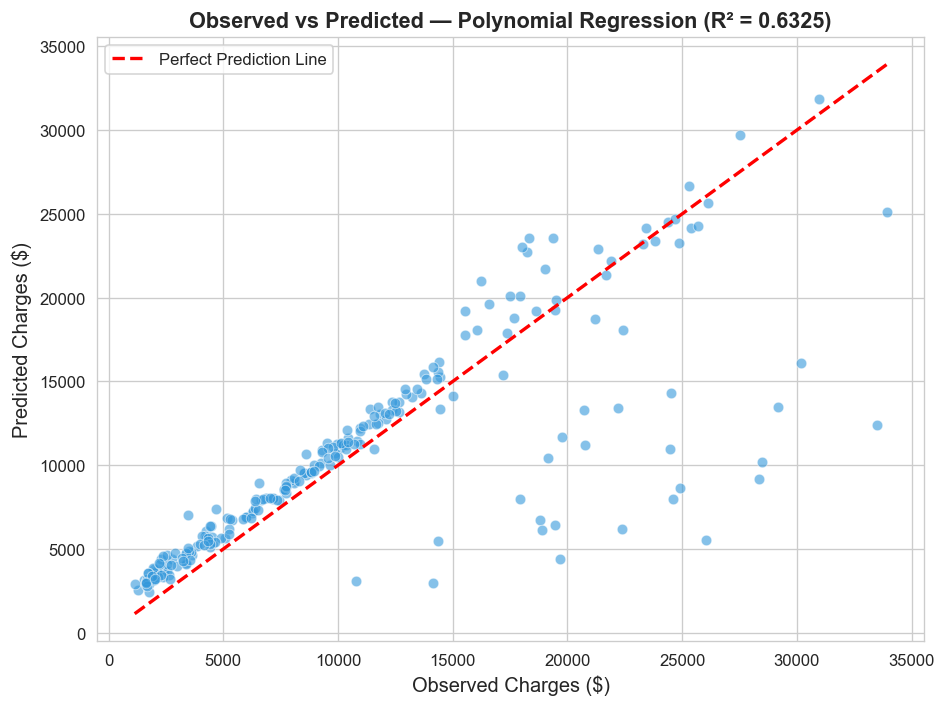

In [14]:
# Scatter plot: Observed vs Predicted for best model
# Using Polynomial Regression predictions (best R²)
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_pr, alpha=0.6, color='#3498db', edgecolors='w', linewidth=0.5, s=40)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction Line')

ax.set_xlabel('Observed Charges ($)', fontsize=12)
ax.set_ylabel('Predicted Charges ($)', fontsize=12)
ax.set_title(f'Observed vs Predicted — Polynomial Regression (R² = {r2_pr:.4f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 11. Predicting from the Regression Equation

In [15]:
# Derive the regression equation and predict 5 random samples
print("=" * 65)
print("  MANUAL PREDICTION USING REGRESSION EQUATION")
print("=" * 65)

# Pick 5 random records from the dataset
np.random.seed(42)
sample_indices = np.random.choice(df_clean.index, size=5, replace=False)
sample_data = df_clean.loc[sample_indices]

print("\nSample records selected:")
print(sample_data.to_string())

# Use best model (Polynomial Regression) to predict
sample_X = sample_data.drop('charges', axis=1)
sample_X_poly = poly.transform(sample_X)
predictions = pr.predict(sample_X_poly)

print("\n" + "-" * 65)
print(f"{'Actual Charges':>20} {'Predicted Charges':>20} {'Difference':>15}")
print("-" * 65)
for actual, predicted in zip(sample_data['charges'], predictions):
    diff = actual - predicted
    print(f"  ${actual:>15,.2f}   ${predicted:>15,.2f}   ${diff:>10,.2f}")
print("=" * 65)

  MANUAL PREDICTION USING REGRESSION EQUATION

Sample records selected:
     age  sex     bmi  children  smoker  region     charges
920   37    0 17.2900         2       0       0  6,877.9801
247   30    1 27.6450         1       0       0  4,237.1265
260   48    0 28.8800         1       0       1  9,249.4952
155   54    1 29.2000         1       0       3 10,436.0960
566   35    0 38.0950         2       0       0 24,915.0463

-----------------------------------------------------------------
      Actual Charges    Predicted Charges      Difference
-----------------------------------------------------------------
  $       6,877.98   $       8,065.59   $ -1,187.61
  $       4,237.13   $       6,048.20   $ -1,811.07
  $       9,249.50   $      10,156.93   $   -907.43
  $      10,436.10   $      11,631.23   $ -1,195.14
  $      24,915.05   $       8,654.49   $ 16,260.56


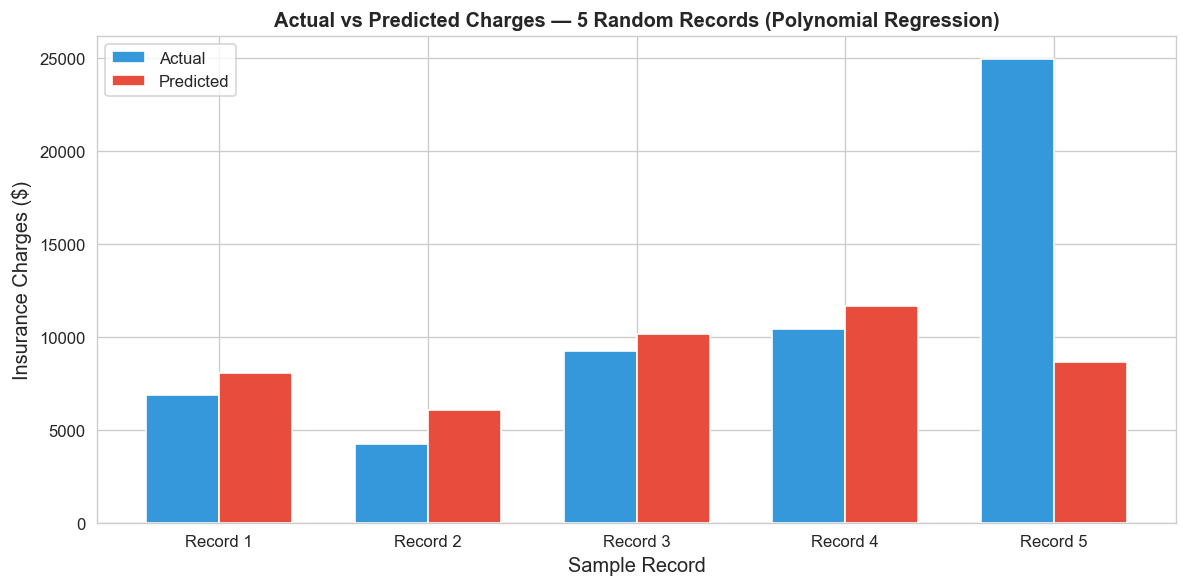

In [16]:
# Plot the 5 sample predictions as bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(predictions))
width = 0.35

bars1 = ax.bar(x_pos - width/2, sample_data['charges'].values, width, label='Actual', color='#3498db', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, predictions, width, label='Predicted', color='#e74c3c', edgecolor='white')

ax.set_xlabel('Sample Record', fontsize=12)
ax.set_ylabel('Insurance Charges ($)', fontsize=12)
ax.set_title('Actual vs Predicted Charges — 5 Random Records (Polynomial Regression)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Record {i+1}' for i in range(5)])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## PART C — CLASSIFICATION MODELS (8 Points)

### 12. Creating the Target Variable for Classification

In [17]:
# Define the target variable as a categorical value based on charges
# Using quantile-based binning for balanced classes
df_class = df_clean.copy()

# Create charge categories: Low, Medium, High based on tertiles
df_class['charge_category'] = pd.qcut(df_class['charges'], q=3, labels=['Low', 'Medium', 'High'])

print("Charge Category Distribution:")
print(df_class['charge_category'].value_counts().sort_index())

print(f"\nCharge ranges per category:")
for cat in ['Low', 'Medium', 'High']:
    subset = df_class[df_class['charge_category'] == cat]['charges']
    print(f"  {cat}: ${subset.min():,.2f} — ${subset.max():,.2f}")

# Encode the target
le_target = LabelEncoder()
df_class['charge_label'] = le_target.fit_transform(df_class['charge_category'])
print(f"\nLabel mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

Charge Category Distribution:
charge_category
Low       397
Medium    397
High      398
Name: count, dtype: int64

Charge ranges per category:
  Low: $1,121.87 — $5,472.45
  Medium: $5,478.04 — $11,365.95
  High: $11,394.07 — $34,472.84

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [18]:
# Prepare features and target for classification
X_cls = df_class.drop(['charges', 'charge_category', 'charge_label'], axis=1)
y_cls = df_class['charge_label']

# Scale features for better performance
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

# Split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("Classification Data Split:")
print(f"  Training: {len(X_train_cls)} samples")
print(f"  Testing:  {len(X_test_cls)} samples")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train_cls, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({le_target.classes_[u]}): {c} samples")

Classification Data Split:
  Training: 953 samples
  Testing:  239 samples

Class distribution in training set:
  Class 0 (High): 318 samples
  Class 1 (Low): 317 samples
  Class 2 (Medium): 318 samples


### 13. Building Classification Models

In [19]:
# ─── Build and evaluate all classifiers ───
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors (K=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine (SVM)': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cls_results = []

for name, model in classifiers.items():
    model.fit(X_train_cls, y_train_cls)
    y_pred = model.predict(X_test_cls)
    
    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred, average='weighted')
    rec = recall_score(y_test_cls, y_pred, average='weighted')
    f1 = f1_score(y_test_cls, y_pred, average='weighted')
    
    cls_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })
    
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print()

  Logistic Regression
  Accuracy:  0.8410
  Precision: 0.8446
  Recall:    0.8410
  F1 Score:  0.8382

  K-Nearest Neighbors (K=5)
  Accuracy:  0.7866
  Precision: 0.7872
  Recall:    0.7866
  F1 Score:  0.7831

  Naive Bayes
  Accuracy:  0.7364
  Precision: 0.8260
  Recall:    0.7364
  F1 Score:  0.6956

  Decision Tree
  Accuracy:  0.7615
  Precision: 0.7634
  Recall:    0.7615
  F1 Score:  0.7620

  Support Vector Machine (SVM)
  Accuracy:  0.8494
  Precision: 0.8608
  Recall:    0.8494
  F1 Score:  0.8446

  Random Forest
  Accuracy:  0.8787
  Precision: 0.8844
  Recall:    0.8787
  F1 Score:  0.8754



### 14. Classification Model Comparison

In [20]:
# Comparison table
cls_comparison = pd.DataFrame(cls_results)
cls_comparison = cls_comparison.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 75)
print("  CLASSIFICATION MODEL COMPARISON")
print("=" * 75)
print(cls_comparison.to_string(index=False))
print("=" * 75)

best_cls = cls_comparison.iloc[0]['Model']
best_acc = cls_comparison.iloc[0]['Accuracy']
print(f"\nBest-Fit Classifier: {best_cls} (Accuracy = {best_acc:.4f})")


  CLASSIFICATION MODEL COMPARISON
                       Model  Accuracy  Precision  Recall  F1 Score
               Random Forest    0.8787     0.8844  0.8787    0.8754
Support Vector Machine (SVM)    0.8494     0.8608  0.8494    0.8446
         Logistic Regression    0.8410     0.8446  0.8410    0.8382
   K-Nearest Neighbors (K=5)    0.7866     0.7872  0.7866    0.7831
               Decision Tree    0.7615     0.7634  0.7615    0.7620
                 Naive Bayes    0.7364     0.8260  0.7364    0.6956

Best-Fit Classifier: Random Forest (Accuracy = 0.8787)


### 15. Confusion Matrix — Best Classifier

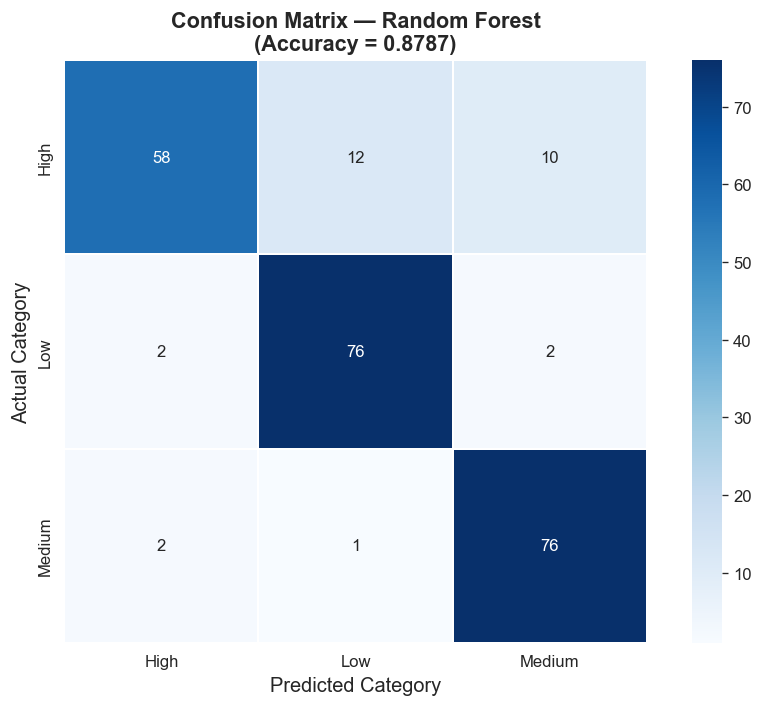


Classification Report — Random Forest:
              precision    recall  f1-score   support

        High       0.94      0.72      0.82        80
         Low       0.85      0.95      0.90        80
      Medium       0.86      0.96      0.91        79

    accuracy                           0.88       239
   macro avg       0.88      0.88      0.88       239
weighted avg       0.88      0.88      0.88       239



In [21]:
# Find the best model and plot its confusion matrix
best_cls_name = cls_comparison.iloc[0]['Model']
best_cls_model = classifiers[best_cls_name]
y_pred_best = best_cls_model.predict(X_test_cls)

cm = confusion_matrix(y_test_cls, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            square=True, linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Category', fontsize=12)
ax.set_ylabel('Actual Category', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_cls_name}\n(Accuracy = {best_acc:.4f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\nClassification Report — {best_cls_name}:")
print(classification_report(y_test_cls, y_pred_best, target_names=le_target.classes_))

### 16. Predicting with Best Classifier — Number of Elements per Category

In [22]:
# Predict on test set using best classifier
y_pred_final = best_cls_model.predict(X_test_cls)

print("=" * 55)
print(f"  PREDICTIONS USING {best_cls_name.upper()}")
print("=" * 55)

print("\nNumber of elements in each category (Test Set):")
print("-" * 40)
for i, label in enumerate(le_target.classes_):
    actual_count = (y_test_cls == i).sum()
    predicted_count = (y_pred_final == i).sum()
    print(f"  {label}: Actual = {actual_count}, Predicted = {predicted_count}")

print(f"\nOverall Accuracy: {accuracy_score(y_test_cls, y_pred_final):.4f}")
print("=" * 55)

  PREDICTIONS USING RANDOM FOREST

Number of elements in each category (Test Set):
----------------------------------------
  High: Actual = 80, Predicted = 62
  Low: Actual = 80, Predicted = 89
  Medium: Actual = 79, Predicted = 88

Overall Accuracy: 0.8787


---
## PART D — CLUSTER ANALYSIS (5 Points)

### 17. Building the K-Means Cluster Model

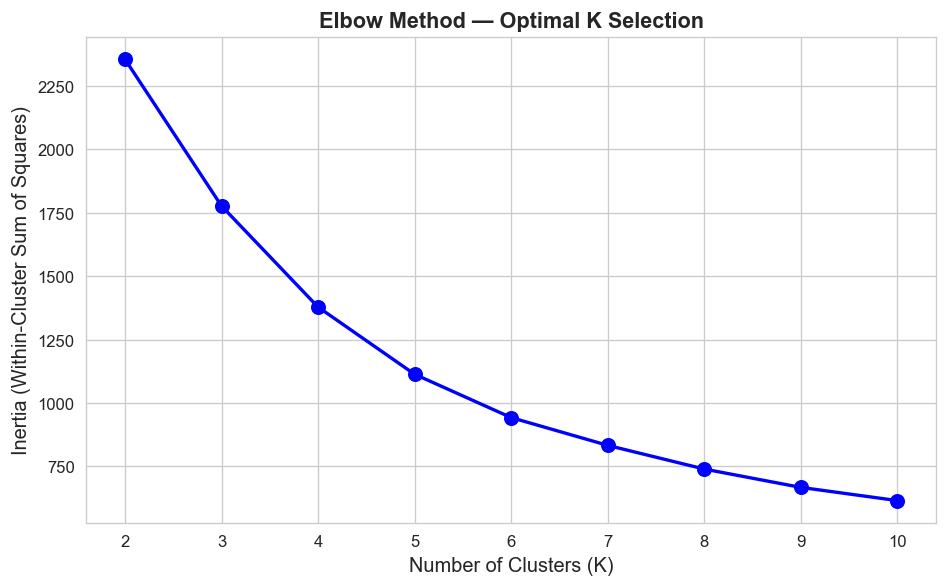

In [23]:
# Prepare data for clustering — use age, bmi, charges (the key numerical features)
cluster_features = ['age', 'bmi', 'charges']
X_cluster = df_clean[cluster_features].copy()

# Standardise for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow Method to determine optimal K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method — Optimal K Selection', fontsize=13, fontweight='bold')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

In [24]:
# Apply K-Means with optimal K = 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster_KMeans'] = kmeans.fit_predict(X_cluster_scaled)

print("=" * 55)
print(f"  K-MEANS CLUSTERING (K = {optimal_k})")
print("=" * 55)
print(f"\nCluster distribution:")
print(df_clean['Cluster_KMeans'].value_counts().sort_index())

print(f"\nCluster centres (original scale):")
centres = scaler_cluster.inverse_transform(kmeans.cluster_centers_)
centres_df = pd.DataFrame(centres, columns=cluster_features)
centres_df.index.name = 'Cluster'
print(centres_df.to_string())

  K-MEANS CLUSTERING (K = 3)

Cluster distribution:
Cluster_KMeans
0    502
1    482
2    208
Name: count, dtype: int64

Cluster centres (original scale):
            age     bmi     charges
Cluster                            
0       27.3539 29.3361  4,093.7700
1       51.6840 31.7792 10,576.8388
2       37.8221 27.4798 22,657.9924


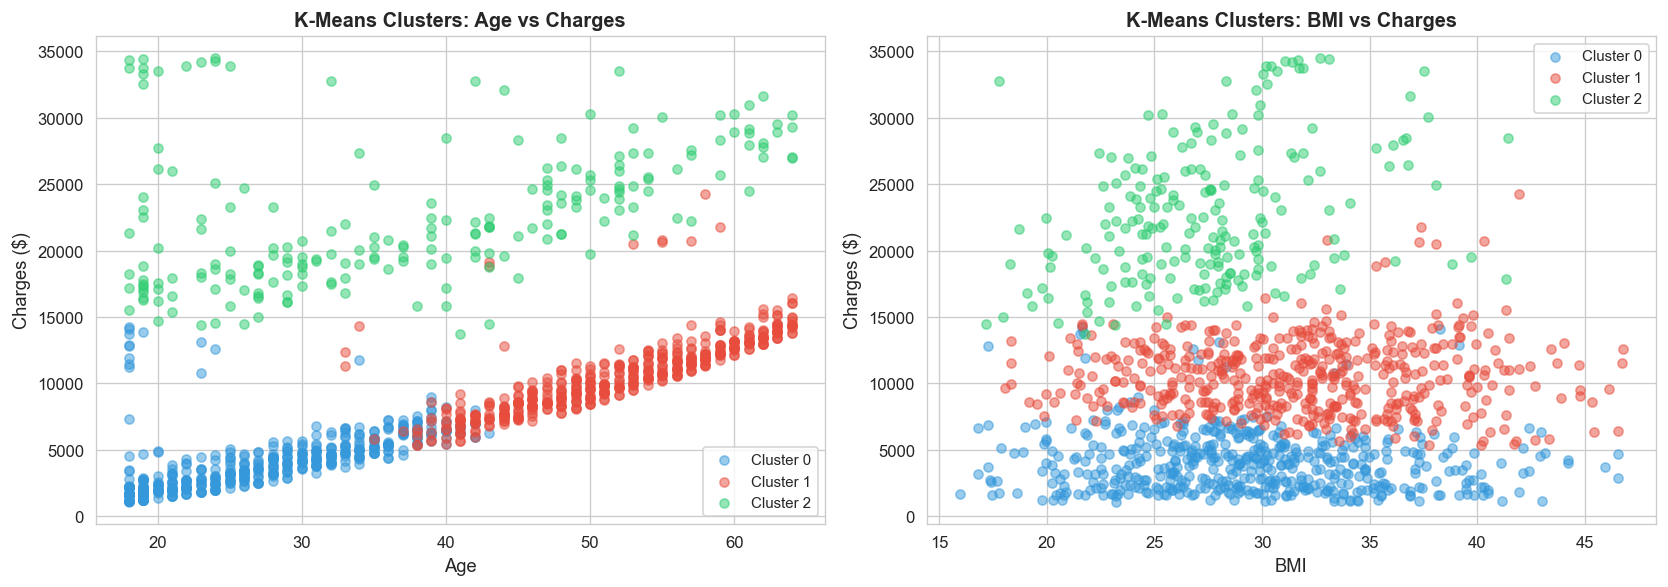

In [25]:
# Visualise K-Means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age vs Charges
colors = ['#3498db', '#e74c3c', '#2ecc71']
for cluster in range(optimal_k):
    mask = df_clean['Cluster_KMeans'] == cluster
    axes[0].scatter(df_clean.loc[mask, 'age'], df_clean.loc[mask, 'charges'],
                    c=colors[cluster], alpha=0.5, label=f'Cluster {cluster}', s=30)
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Charges ($)', fontsize=11)
axes[0].set_title('K-Means Clusters: Age vs Charges', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Plot 2: BMI vs Charges
for cluster in range(optimal_k):
    mask = df_clean['Cluster_KMeans'] == cluster
    axes[1].scatter(df_clean.loc[mask, 'bmi'], df_clean.loc[mask, 'charges'],
                    c=colors[cluster], alpha=0.5, label=f'Cluster {cluster}', s=30)
axes[1].set_xlabel('BMI', fontsize=11)
axes[1].set_ylabel('Charges ($)', fontsize=11)
axes[1].set_title('K-Means Clusters: BMI vs Charges', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 18. Hierarchical Clustering

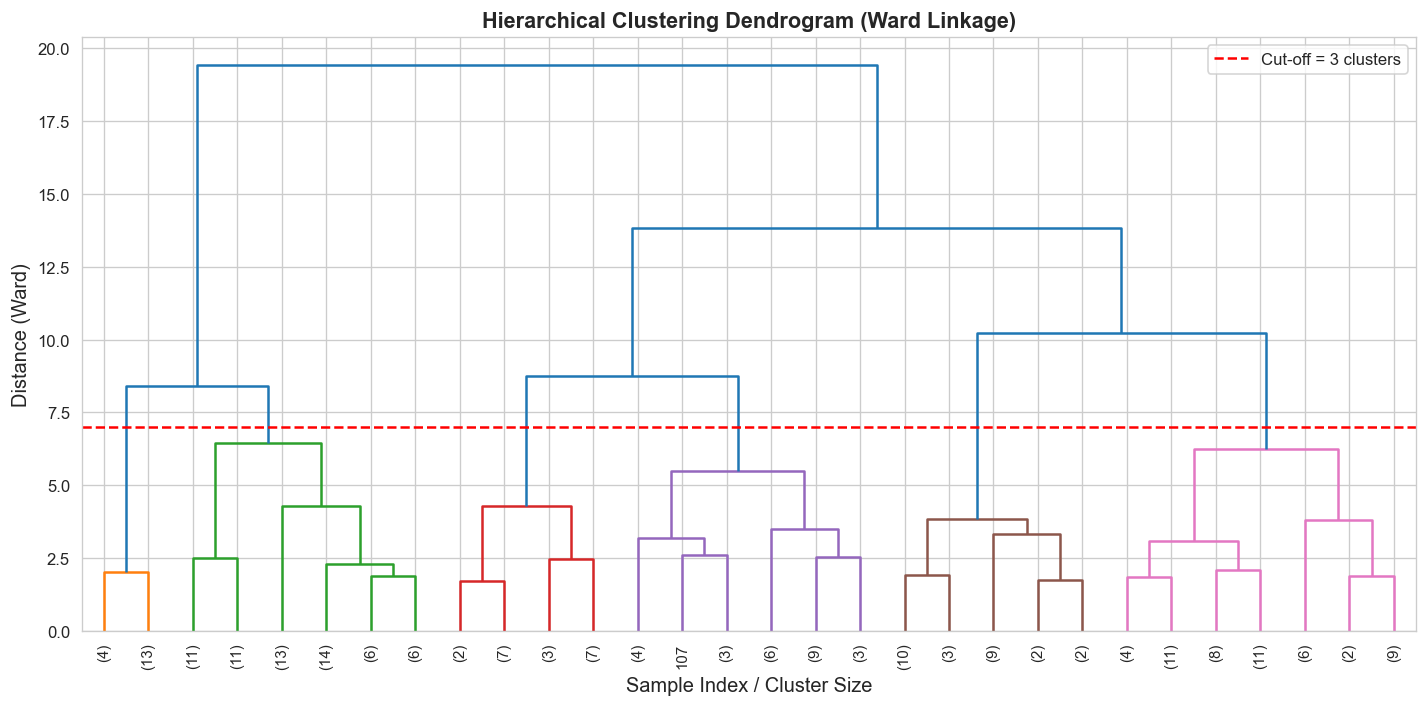

In [26]:
# Hierarchical clustering — dendrogram (using a subset for readability)
np.random.seed(42)
sample_idx = np.random.choice(len(X_cluster_scaled), size=200, replace=False)
X_sample = X_cluster_scaled[sample_idx]

# Compute linkage
linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, ax=ax,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=7)
ax.set_xlabel('Sample Index / Cluster Size', fontsize=12)
ax.set_ylabel('Distance (Ward)', fontsize=12)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
ax.axhline(y=7, color='red', linestyle='--', linewidth=1.5, label='Cut-off = 3 clusters')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
# Apply Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3)
df_clean['Cluster_Hierarchical'] = agg.fit_predict(X_cluster_scaled)

print("=" * 55)
print("  HIERARCHICAL CLUSTERING (K = 3)")
print("=" * 55)
print(f"\nCluster distribution:")
print(df_clean['Cluster_Hierarchical'].value_counts().sort_index())

# Cluster profiles
print(f"\nCluster profiles (mean values):")
profiles = df_clean.groupby('Cluster_Hierarchical')[cluster_features].mean()
print(profiles.to_string())

  HIERARCHICAL CLUSTERING (K = 3)

Cluster distribution:
Cluster_Hierarchical
0    570
1    391
2    231
Name: count, dtype: int64

Cluster profiles (mean values):
                         age     bmi     charges
Cluster_Hierarchical                            
0                    49.2491 30.8126  9,639.5771
1                    25.0384 30.0585  3,309.7365
2                    37.3333 27.8858 21,951.6115


### 19. Cluster Strategy Analysis

In [28]:
# Detailed cluster analysis for K-Means
print("=" * 65)
print("  CLUSTER STRATEGY ANALYSIS (K-Means, K=3)")
print("=" * 65)

for cluster in range(optimal_k):
    mask = df_clean['Cluster_KMeans'] == cluster
    subset = df_clean[mask]
    print(f"\n--- Cluster {cluster} ({len(subset)} members) ---")
    print(f"  Avg Age:     {subset['age'].mean():.1f} years")
    print(f"  Avg BMI:     {subset['bmi'].mean():.1f}")
    print(f"  Avg Charges: ${subset['charges'].mean():,.2f}")
    print(f"  Min Charges: ${subset['charges'].min():,.2f}")
    print(f"  Max Charges: ${subset['charges'].max():,.2f}")
    smoker_pct = (subset['smoker'].sum() / len(subset)) * 100
    print(f"  Smoker %:    {smoker_pct:.1f}%")

print("\n" + "=" * 65)

  CLUSTER STRATEGY ANALYSIS (K-Means, K=3)

--- Cluster 0 (502 members) ---
  Avg Age:     27.3 years
  Avg BMI:     29.3
  Avg Charges: $4,087.67
  Min Charges: $1,121.87
  Max Charges: $14,283.46
  Smoker %:    0.8%

--- Cluster 1 (482 members) ---
  Avg Age:     51.7 years
  Avg BMI:     31.8
  Avg Charges: $10,569.74
  Min Charges: $5,397.62
  Max Charges: $24,227.34
  Smoker %:    0.0%

--- Cluster 2 (208 members) ---
  Avg Age:     37.8 years
  Avg BMI:     27.5
  Avg Charges: $22,657.99
  Min Charges: $13,725.47
  Max Charges: $34,472.84
  Smoker %:    64.4%



---
## References

- Choi, M. (2018). Medical Cost Personal Dataset. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression. *Technometrics*, 12(1), 55–67.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *JRSS-B*, 58(1), 267–288.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *JRSS-B*, 67(2), 301–320.
- McKinney, W. (2022). pandas: Powerful Python data analysis toolkit. https://pandas.pydata.org/
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362.
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. *JOSS*, 6(60), 3021.